In [13]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [24]:
t_in  = 70
files = sorted(glob.glob("../data/2D/chunk_*.npz"))

X_list, Y_list = [], []
for f in files:
    d = np.load(f, allow_pickle=True)
    i = np.where(d["snap_times"] == t_in)[0][0]
    X_list.append(d["snaps"][:, i])
    Y_list.append(d["phi_final"] > 0)

X = np.concatenate(X_list).astype(np.float32)    # (3000, 128, 128)
Y = np.concatenate(Y_list).astype(np.float32)    # (3000, 128, 128)
print(len(files), "chunks", X.shape, Y.shape)

60 chunks (3000, 128, 128) (3000, 128, 128)


In [ ]:
rng = np.random.default_rng(0)
idx = rng.permutation(len(X))
n10 = len(X) // 10
test_idx, val_idx, train_idx = idx[:n10], idx[n10:2*n10], idx[2*n10:]

scale = X[train_idx].std()

def loader(ids, shuffle):
    Xt = torch.from_numpy(X[ids][:, None] / scale)
    Yt = torch.from_numpy(Y[ids][:, None])
    return DataLoader(TensorDataset(Xt, Yt), batch_size=32, shuffle=shuffle)

train_loader = loader(train_idx, True)
val_loader   = loader(val_idx,   False)
test_loader  = loader(test_idx,  False)

base = ((X[test_idx] > 0) == (Y[test_idx] > 0.5)).mean()
print(f"train {len(train_idx)}, val {len(val_idx)}, test {len(test_idx)}")
print(f"baseline test accuracy: {base:.3f}")

train 2400, val 300, test 300
baseline test accuracy: 0.917


In [26]:
def block(c_in, c_out):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1, padding_mode="circular"), nn.ReLU(),
        nn.Conv2d(c_out, c_out, 3, padding=1, padding_mode="circular"), nn.ReLU(),
    )

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.up   = nn.Upsample(scale_factor=2)
        self.down1  = block(1, 16)
        self.down2  = block(16, 32)
        self.down3  = block(32, 64)
        self.bottom = block(64, 128)
        self.up3 = block(128 + 64, 64)
        self.up2 = block(64 + 32, 32)
        self.up1 = block(32 + 16, 16)
        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool(d1))
        d3 = self.down3(self.pool(d2))
        b  = self.bottom(self.pool(d3))
        u3 = self.up3(torch.cat([self.up(b),  d3], dim=1))
        u2 = self.up2(torch.cat([self.up(u3), d2], dim=1))
        u1 = self.up1(torch.cat([self.up(u2), d1], dim=1))
        return self.out(u1)

In [27]:
loss_fn = nn.BCEWithLogitsLoss()

def evaluate(model, loader):
    total_loss, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += loss_fn(logits, yb).item() * len(xb)
            correct    += ((logits > 0) == (yb > 0.5)).sum().item()
            count      += yb.numel()
    return total_loss / len(loader.dataset), correct / count

In [28]:
import time

model = UNet().to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)

history  = []
best_val = 0.0
ckpt     = f"unet_t{t_in}.pt"

for epoch in range(30):
    t0 = time.time()
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(model(xb), yb)
        opt.zero_grad()
        loss.backward()
        opt.step()

    model.eval()
    train_loss, train_acc = evaluate(model, train_loader)
    val_loss,   val_acc   = evaluate(model, val_loader)
    history.append((train_loss, val_loss, train_acc, val_acc))

    saved = ""
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), ckpt)
        saved = "  *saved"

    print(f"epoch {epoch:2d}  train {train_acc:.4f}  val {val_acc:.4f}  "
          f"({time.time()-t0:.0f}s){saved}", flush=True)

epoch  0  train 0.9539  val 0.9556  (4s)  *saved
epoch  1  train 0.9852  val 0.9862  (4s)  *saved
epoch  2  train 0.9810  val 0.9819  (4s)
epoch  3  train 0.9838  val 0.9846  (4s)
epoch  4  train 0.9890  val 0.9894  (4s)  *saved
epoch  5  train 0.9872  val 0.9877  (4s)
epoch  6  train 0.9925  val 0.9928  (4s)  *saved
epoch  7  train 0.9940  val 0.9942  (4s)  *saved
epoch  8  train 0.9941  val 0.9941  (4s)
epoch  9  train 0.9934  val 0.9936  (4s)
epoch 10  train 0.9847  val 0.9855  (4s)
epoch 11  train 0.9953  val 0.9954  (4s)  *saved
epoch 12  train 0.9956  val 0.9957  (4s)  *saved
epoch 13  train 0.9944  val 0.9945  (4s)
epoch 14  train 0.9959  val 0.9959  (4s)  *saved
epoch 15  train 0.9892  val 0.9897  (4s)
epoch 16  train 0.9961  val 0.9961  (4s)  *saved
epoch 17  train 0.9956  val 0.9957  (4s)
epoch 18  train 0.9951  val 0.9951  (4s)
epoch 19  train 0.9962  val 0.9962  (4s)  *saved
epoch 20  train 0.9927  val 0.9928  (4s)
epoch 21  train 0.9952  val 0.9953  (4s)
epoch 22  train 0.

test accuracy  0.9967
baseline       0.9169
error rate cut by 96.0%


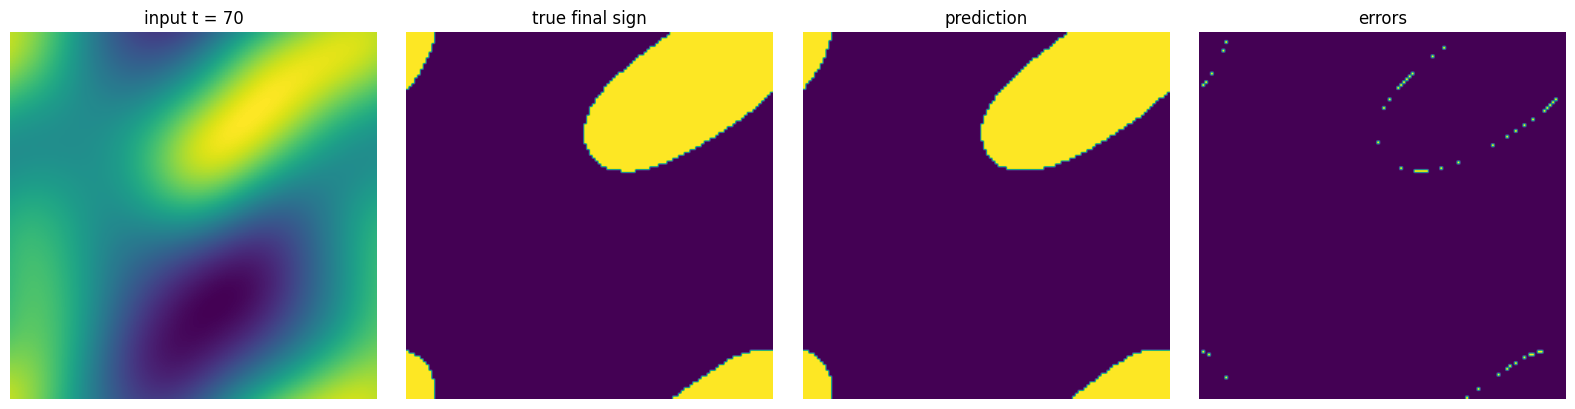

In [31]:
model.load_state_dict(torch.load(ckpt))
model.eval()

test_loss, test_acc = evaluate(model, test_loader)
print(f"test accuracy  {test_acc:.4f}")
print(f"baseline       {base:.4f}")
print(f"error rate cut by {100*(1 - (1-test_acc)/(1-base)):.1f}%")

xb, yb = next(iter(test_loader))
with torch.no_grad():
    pred = (model(xb.to(device)) > 0).cpu()

n = 0
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(xb[n, 0]);                        axes[0].set_title(f"input t = {t_in}")
axes[1].imshow(yb[n, 0]);                        axes[1].set_title("true final sign")
axes[2].imshow(pred[n, 0]);                      axes[2].set_title("prediction")
axes[3].imshow(pred[n, 0] != (yb[n, 0] > 0.5));  axes[3].set_title("errors")
for a in axes: a.axis("off")
plt.tight_layout()
plt.savefig(f"../figures/pred_t{t_in}.png", dpi=150)
plt.show()

test accuracy  0.9967
baseline       0.9169
error rate cut by 96.0%


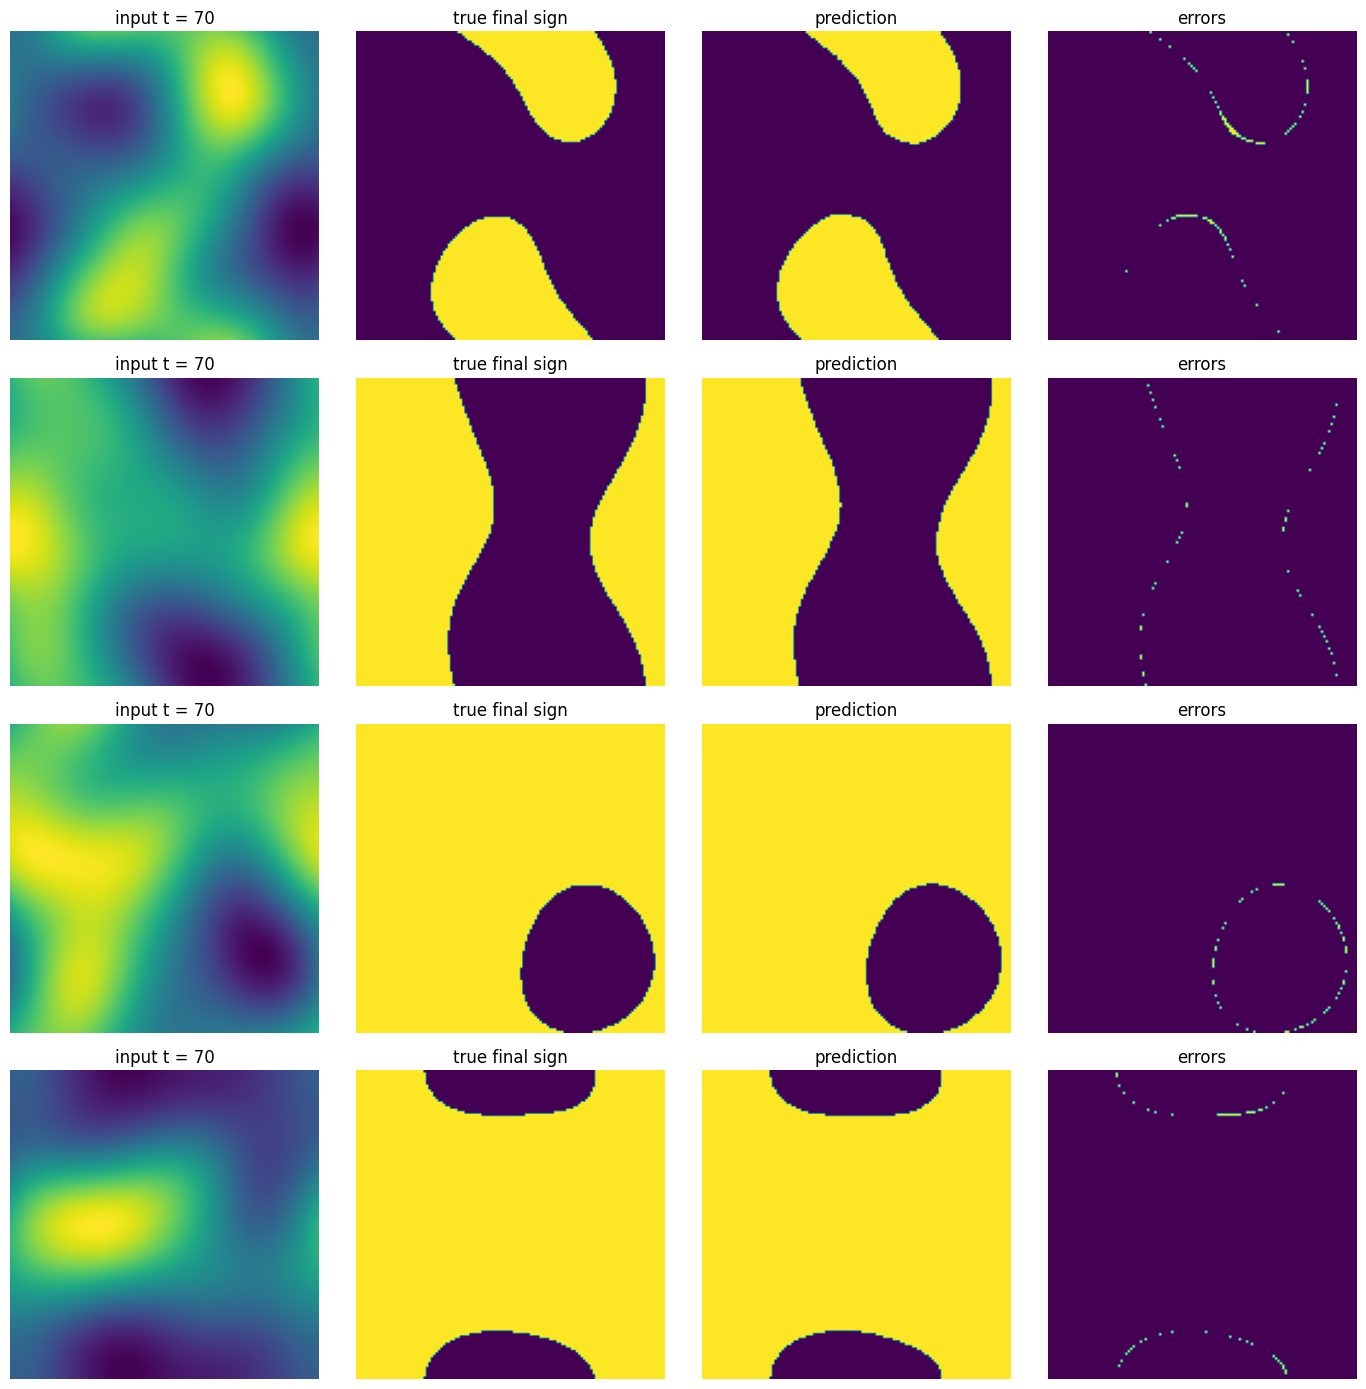

In [32]:
model.load_state_dict(torch.load(ckpt))
model.eval()

test_loss, test_acc = evaluate(model, test_loader)
print(f"test accuracy  {test_acc:.4f}")
print(f"baseline       {base:.4f}")
print(f"error rate cut by {100*(1 - (1-test_acc)/(1-base)):.1f}%")

# random test samples
rng   = np.random.default_rng()
picks = rng.choice(len(test_idx), size=4, replace=False)

Xs = torch.from_numpy(X[test_idx][picks][:, None] / scale)
Ys = Y[test_idx][picks] > 0.5

with torch.no_grad():
    pred = (model(Xs.to(device)) > 0).cpu().numpy()[:, 0]

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for r in range(4):
    axes[r, 0].imshow(Xs[r, 0]);                 axes[r, 0].set_title(f"input t = {t_in}")
    axes[r, 1].imshow(Ys[r]);                    axes[r, 1].set_title("true final sign")
    axes[r, 2].imshow(pred[r]);                  axes[r, 2].set_title("prediction")
    axes[r, 3].imshow(pred[r] != Ys[r]);         axes[r, 3].set_title("errors")
    for a in axes[r]: a.axis("off")
plt.tight_layout()
plt.savefig(f"../figures/pred_t{t_in}.png", dpi=150)
plt.show()

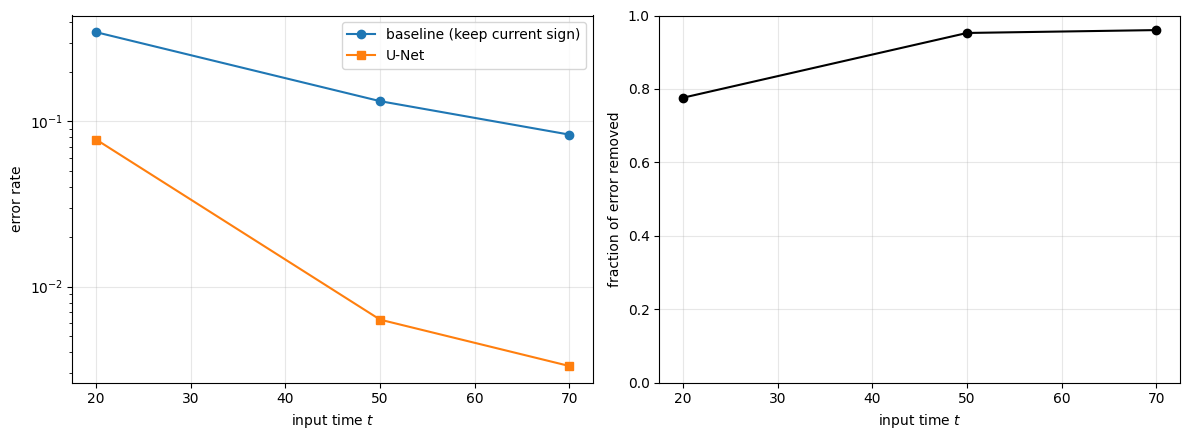

In [33]:
t     = np.array([20, 50, 70])
base  = np.array([0.6534, 0.8675, 0.9169])
model = np.array([0.9224, 0.9937, 0.9967])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# error rate
axes[0].semilogy(t, 1 - base,  "o-", label="baseline (keep current sign)")
axes[0].semilogy(t, 1 - model, "s-", label="U-Net")
axes[0].set_xlabel("input time $t$")
axes[0].set_ylabel("error rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

# fraction of baseline error removed
axes[1].plot(t, 1 - (1 - model)/(1 - base), "o-", color="k")
axes[1].set_xlabel("input time $t$")
axes[1].set_ylabel("fraction of error removed")
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/accuracy_vs_time.png", dpi=150)
plt.show()